In [2]:
# %matplotlib inline
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.style.use('seaborn-white')
import multiprocess as mp
import numpy as np
import pandas as pd
import bioframe
import cooltools
import cooler
#import bbi
#from cooltools import snipping
from cooltools.lib import numutils

/tmp/ipykernel_40578/161901901.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn-white')


In [2]:
%matplotlib inline

In [ ]:
# make matplotlib pdf-s text recognizable by evil-Adobe
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] ='path'
matplotlib.rcParams['ps.fonttype'] = 42

In [ ]:
hg38 = bioframe.fetch_chromsizes('hg38')
chromsizes = bioframe.fetch_chromsizes('hg38')
chromosomes = list(chromsizes.index)

In [5]:
filename1="OU-HiC-Control-Fib-D4__hg38.hg38.mapq_30.1000.mcool"
filename2="OU-HiC-Control-Fib-D16__hg38.hg38.mapq_30.1000.mcool"
filename3="OU-HiC-N6-IPSC__hg38.hg38.mapq_30.1000.mcool"
filename4="OU-HiC-N9-IPSC__hg38.hg38.mapq_30.1000.mcool"
filename5="OU-HiC-N6-iPSN-D45__hg38.hg38.mapq_30.1000.mcool"
filename6="OU-HiC-N9-iPSN-D45__hg38.hg38.mapq_30.1000.mcool"
filename7="OU-HiC-N9-N6-MN-W6__hg38.hg38.mapq_30.1000.mcool"
filename8="OU-HiC-Control-iPSN-D45__hg38.hg38.mapq_30.1000.mcool"

In [7]:
hg38 = bioframe.fetch_chromsizes('hg38')
chromsizes = bioframe.fetch_chromsizes('hg38')
chromosomes = list(chromsizes.index)

print(filename1,filename2,filename3,filename4,filename5,filename6,filename7,filename8)

conditions = ['Fib-D4' ,
    'Fib-D16' ,
    'N6-All' ,
    'EP-W0' ,
    'MN-W0' ,
    'MN-W3',
    'MN-W6',
    'iPSN-D45']


cool = [filename1,filename2,filename3,filename4,filename5,filename6,filename7,filename8]


cooler_paths = {    
    'Fib-D4' : path2+filename1+'::/resolutions/1000000',
    'Fib-D16' : path2+filename2+'::/resolutions/1000000',
    'N6-All' : path2+filename3+'::/resolutions/1000000',
    'EP-W0' : path2+filename4+'::/resolutions/1000000',
    'MN-W0' : path2+filename5+'::/resolutions/1000000',
    'MN-W3' : path2+filename6+'::/resolutions/1000000',
    'MN-W6' : path2+filename7+'::/resolutions/1000000',
    'iPSN-D45' : path2+filename8+'::/resolutions/1000000',

}


#tracks = {    
    #'2_2' : path3+track1+'::/resolutions/250000',
    #'2_10' : path3+track2+'::/resolutions/250000',
    #'11_100' : path3+track3+'::/resolutions/250000',
    #'101_1000' : path3+track4+'::/resolutions/250000',
    #'1001_10000' : path3+track5+'::/resolutions/250000',
    #'2_10000' : path3+track6+'::/resolutions/250000',
    #'2_100' : path3+track7+'::/resolutions/250000',
    #'All' : path3+track8+'::/resolutions/250000'
#    }
    
    

long_names = {
    'Fib-D4' : 'Fib-D4',
    'Fib-D16' : 'Fib-D16',
    'N6-All' : 'N6-All',
    'EP-W0' : 'EP-W0',
    'MN-W0' : 'MN-W0',
    'MN-W3' : 'MN-W3',
    'MN-W6' : 'MN-W6',
    'iPSN-D45' : 'iPSN-D45'
}

clrs = {
    cond: cooler.Cooler(cooler_paths[cond]) for cond in conditions
}



OU-HiC-Control-Fib-D4__hg38.hg38.mapq_30.1000.mcool OU-HiC-Control-Fib-D16__hg38.hg38.mapq_30.1000.mcool OU-HiC-N6-IPSC__hg38.hg38.mapq_30.1000.mcool OU-HiC-N9-N6-EP-W0__hg38.hg38.mapq_30.1000.mcool OU-HiC-N9-N6-MN-W0__hg38.hg38.mapq_30.1000.mcool OU-HiC-N9-N6-MN-W3__hg38.hg38.mapq_30.1000.mcool OU-HiC-N9-N6-MN-W6__hg38.hg38.mapq_30.1000.mcool OU-HiC-Control-iPSN-D45__hg38.hg38.mapq_30.1000.mcool


In [8]:
cmap2 = mpl.colors.LinearSegmentedColormap.from_list('mycmap', ['#FFFFFF', '#F5A623', '#D0021B', '#000000'])
#cmap2.set_bad(color='grey') #this works to set NAs as grey, but this data isn't deep enough, doesn't look nice

691 882
191
1395 1541


691 882
191
1395 1541
691 882
191
1395 1541
691 882
191
1395 1541
691 882
191
1395 1541
691 882
191
1395 1541
691 882
191
1395 1541
691 882
191
1395 1541


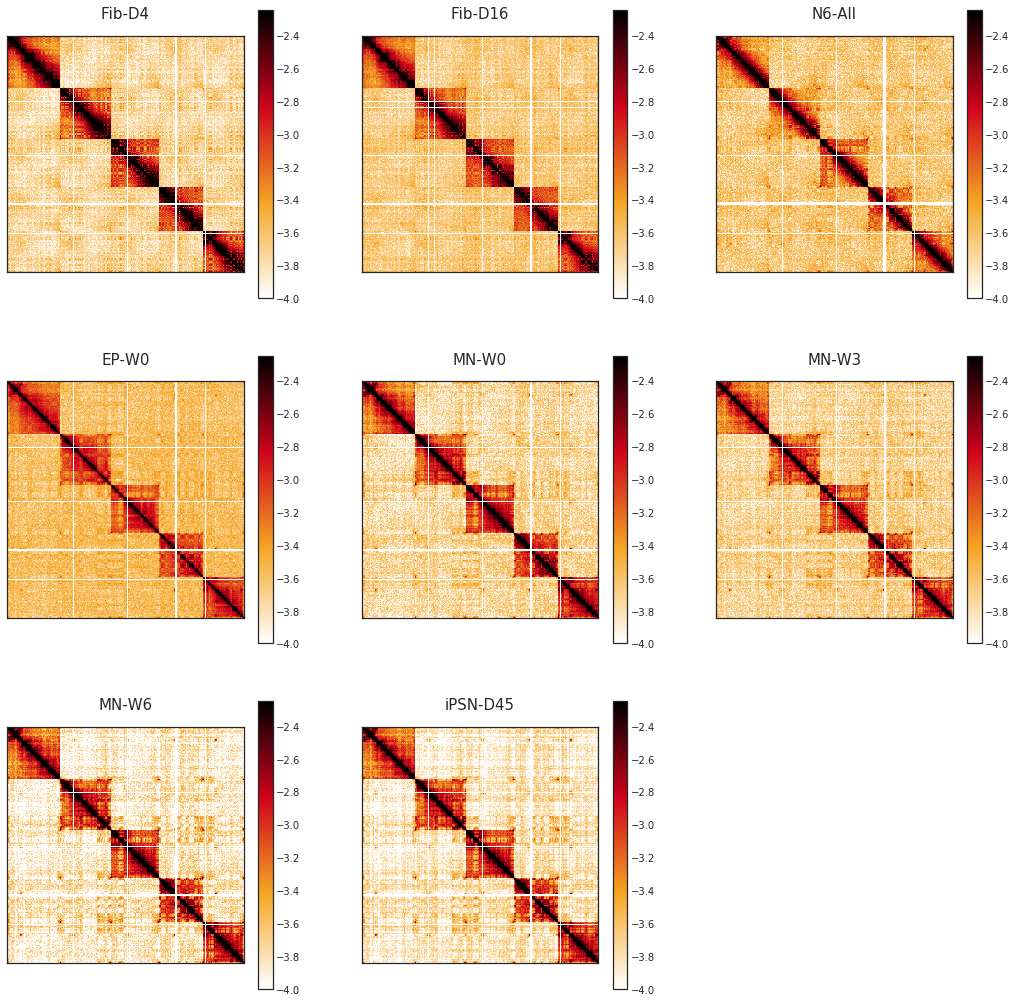

In [16]:
fig = plt.figure(figsize=(18,18))
gs = gridspec.GridSpec(nrows=3,ncols=3)
k=0
for k,cond in enumerate(conditions):
    ax = plt.subplot(gs[k])
    x,y=clrs[cond].extent("chr4")
    x1,y1=clrs[cond].extent("chr8")
    #x=x+300
    #y=x+300
    print(x,y)
    print(y-x)
    #x1=x+10
    #y1=x+250
    print(x1,y1)
    mat = clrs[cond].matrix(balance=True, sparse=True)[x:y1,x:y1]
    arr = mat.toarray()
    im =ax.matshow(np.log10(arr), cmap=cmap2,vmin=-4,vmax=-2.25)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(long_names[cond], fontdict={'fontsize': 15, 'fontweight': 'medium'})
    k=k+1
    
    #colorAx = plt.subplot(gs[k])
    #cb = plt.colorbar(im, cax = colorAx, extend = 'both')
    #cb.set_label('log10(normalized interactions)')
    #ax.set_aspect('equal')
    #k=k+1
    
    plt.colorbar(im)
plt.savefig('HiC_lib_groups_all_balanced_1MB_chr4-8_N6all.pdf')